# Cuaderno 3: Operaciones básicas con OpenCV

Ahora que ya trabajaste con color y canales, vamos a usar `OpenCV` para hacer operaciones básicas sobre imágenes: cargar, describir, recortar, redimensionar, detectar bordes y segmentar por umbral.

## Objetivos

- Leer imágenes con `OpenCV`.
- Reconocer dimensiones y tipo de dato.
- Hacer recortes y cambios de tamaño.
- Aplicar una detección de bordes simple.
- Probar una segmentación por umbral en escala de grises.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski

base = Path(".")

paisaje = base / "paisaje.png"
monedas = base / "monedas.png"

if not paisaje.exists():
    cv2.imwrite(str(paisaje), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))

if not monedas.exists():
    cv2.imwrite(str(monedas), ski.data.coins())


def describir_imagen(imagen, nombre="Imagen"):
    print(f"{nombre}")
    print(f"  forma: {imagen.shape}")
    print(f"  tipo de dato: {imagen.dtype}")
    print(f"  valor mínimo: {imagen.min()}")
    print(f"  valor máximo: {imagen.max()}")


## 1. Cargar y describir una imagen color

Antes de modificar una imagen, conviene mirar cuatro cosas: su forma, su tipo de dato, su valor mínimo y su valor máximo. Es una forma simple de entender con qué material estamos trabajando.


Paisaje leído con OpenCV
  forma: (225, 225, 3)
  tipo de dato: uint8
  valor mínimo: 0
  valor máximo: 255


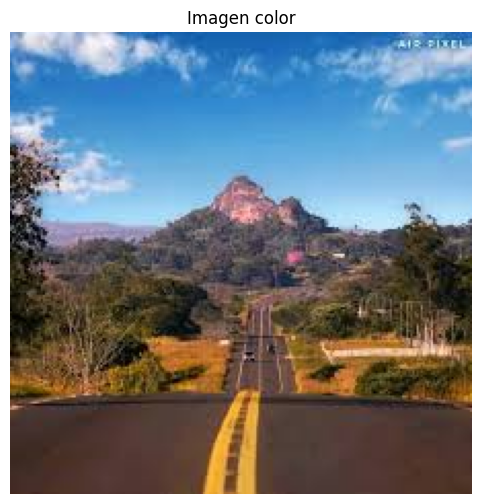

In [2]:
img_bgr = cv2.imread(str(paisaje))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

describir_imagen(img_bgr, "Paisaje leído con OpenCV")

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Imagen color")
plt.axis("off")
plt.show()


## 2. Recorte y cambio de tamaño

Un recorte selecciona una región puntual de la imagen. Redimensionar, en cambio, cambia el tamaño de una imagen o de un recorte.

No son la misma operación: recortar quita información alrededor; redimensionar conserva el contenido del recorte, pero lo reescala.


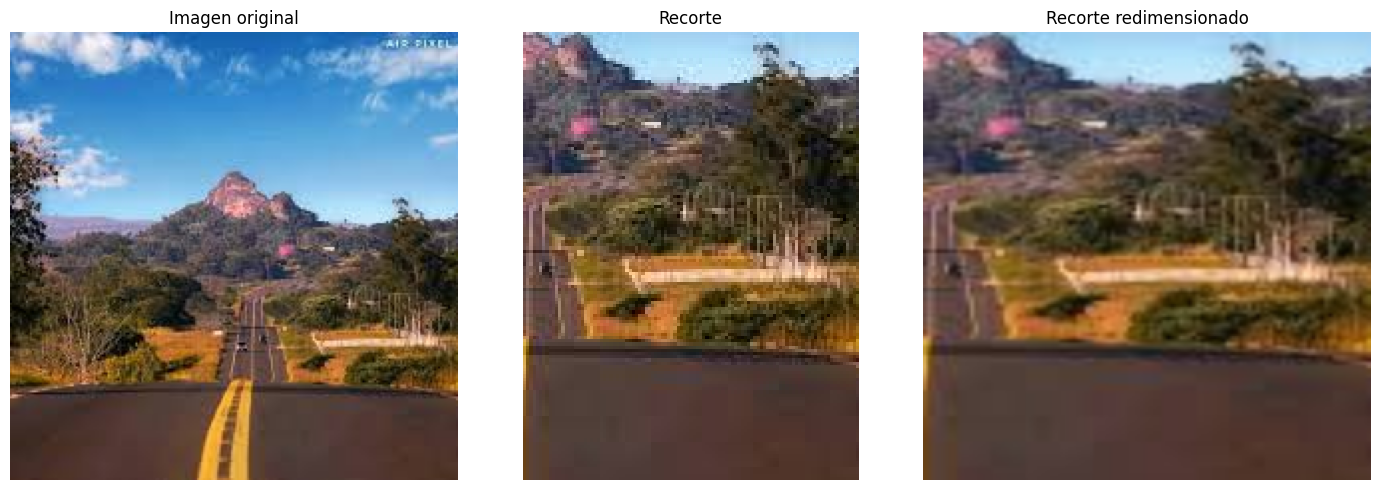

In [3]:
recorte = img_rgb[80:220, 120:260]
recorte_grande = cv2.resize(recorte, (280, 280))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(recorte)
axes[1].set_title("Recorte")
axes[1].axis("off")

axes[2].imshow(recorte_grande)
axes[2].set_title("Recorte redimensionado")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 3. Bordes en una imagen en escala de grises

Para muchas operaciones conviene trabajar en escala de grises. En esta parte usamos una imagen de monedas para probar el detector de bordes `Canny` con dos configuraciones distintas.


Monedas en escala de grises
  forma: (303, 384)
  tipo de dato: uint8
  valor mínimo: 1
  valor máximo: 252


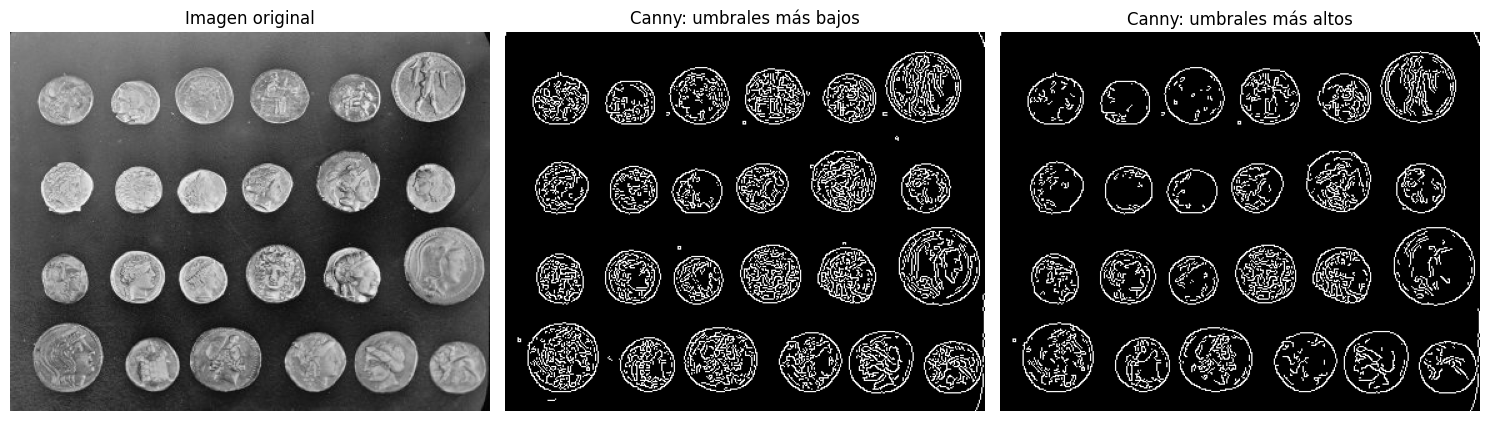

In [4]:
img_monedas = cv2.imread(str(monedas), cv2.IMREAD_GRAYSCALE)

describir_imagen(img_monedas, "Monedas en escala de grises")

bordes_suaves = cv2.Canny(img_monedas, 80, 140)
bordes_estrictos = cv2.Canny(img_monedas, 140, 220)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_monedas, cmap="gray")
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(bordes_suaves, cmap="gray")
axes[1].set_title("Canny: umbrales más bajos")
axes[1].axis("off")

axes[2].imshow(bordes_estrictos, cmap="gray")
axes[2].set_title("Canny: umbrales más altos")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 4. Segmentación por umbral

Segmentar por umbral consiste en separar píxeles claros y oscuros a partir de un valor de corte. No es un método universal, pero es una muy buena puerta de entrada para entender cómo se construye una máscara binaria.


Área segmentada con umbral 100: 48864 píxeles
Área segmentada con umbral 150: 23765 píxeles


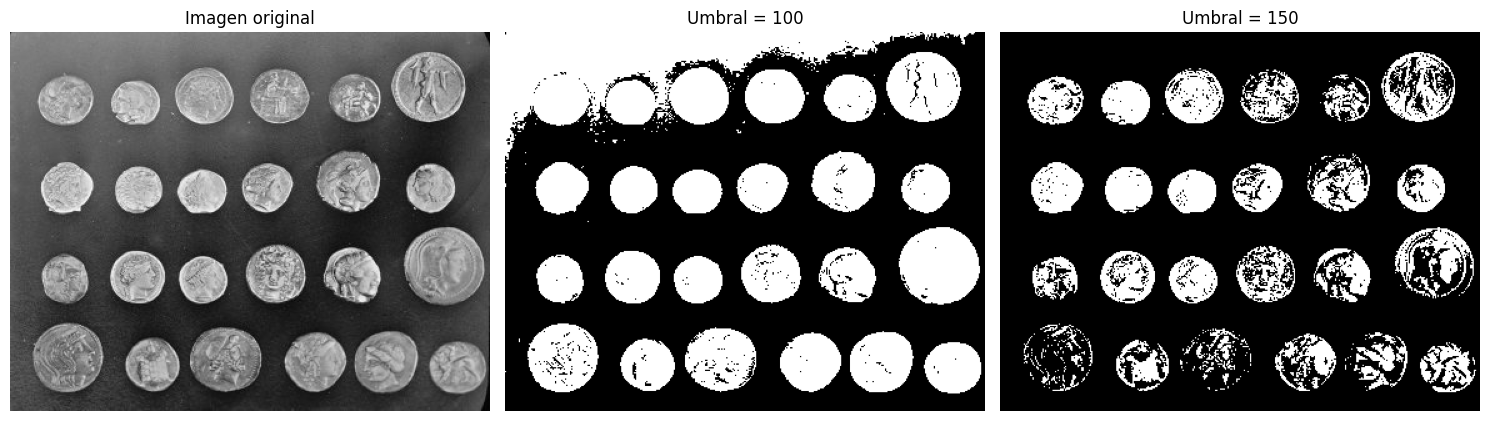

In [5]:
def segmentar_por_umbral(imagen, umbral):
    mascara = np.zeros_like(imagen, dtype=np.uint8)
    mascara[imagen > umbral] = 255
    area = np.sum(mascara == 255)
    print(f"Área segmentada con umbral {umbral}: {area} píxeles")
    return mascara


seg_100 = segmentar_por_umbral(img_monedas, 100)
seg_150 = segmentar_por_umbral(img_monedas, 150)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_monedas, cmap="gray")
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(seg_100, cmap="gray")
axes[1].set_title("Umbral = 100")
axes[1].axis("off")

axes[2].imshow(seg_150, cmap="gray")
axes[2].set_title("Umbral = 150")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Cierre

En este cuaderno usaste `OpenCV` para aplicar operaciones básicas. Lo importante no es memorizar cada línea, sino reconocer qué cambia cuando recortás, redimensionás, detectás bordes o aplicás un umbral.

En los próximos materiales vamos a profundizar en dos ideas que se relacionan con todo esto: el muestreo y la cuantización.
